# redshift (z) 
$\rightarrow$ **calcul du redshift de galaxies**

## le cours 

3C 273 est un Quasar de type FSRQ (Flat Spectrum Radio Quasar)
- C'est un Noyau Galactique Actif (AGN) extrêmement lumineux.
- Le spectre de 3C 273 est dominé par des raies d'émission très larges ( $\text{H}\alpha$, $\text{H}\beta$, $\text{MgII}$, $\text{CIII}]$...).
- Cette largeur indique un gaz se déplaçant à des milliers de kilomètres par seconde dans la Région à Raies Larges (BLR).

La Vitesse de "Turbulence" (FWHM) est de 57.43 Å, ce qui donne en vitesse pour H-beta :$$V_{FWHM} = c \times \frac{FWHM}{\lambda_{obs}} \approx 299792 \times \frac{57.43}{5633.76} \approx 3056 \text{ km/s}$$

-> Le gaz autour du trou noir tourne à plus de 3000 km/s. C'est ce qui différencie un Quasar (raies larges) d'une galaxie normale (raies fines).



NGC 7215 est classée comme une Galaxie de Seyfert de Type 1.5.
- C'est un type de galaxie dont le noyau est très brillant (un Noyau Galactique Actif ou AGN).
- Ce noyau est alimenté par un trou noir supermassif (SMBH) qui accrète de la matière.
- La classification **Seyfert** se base sur l'apparence des raies d'émission dans le spectre, qui proviennent de différentes régions autour du trou noir :
    - Raies Étroites (NLR - Narrow Line Region) : Gaz éloigné qui donne des raies fines (comme $[\text{OIII}]$ et $[\text{SII}]$) .
    - Raies Larges (BLR - Broad Line Region) : Gaz très proche du trou noir, se déplaçant très rapidement, ce qui élargit fortement les raies d'hydrogène


On peut estimer la masse du trou noir via le théorème du Viriel, où la masse est liée à la vitesse du gaz ($V$) et au rayon de la BLR ($R_{BLR}$) :

... A faire :-) 

## les données

|||
|---|---|
|OBJECT|	3c273|
|EXPTIME2|	5 x 60 s|
|BSS_ITRP|	500|
|SPE_RPOW|	500|
|BSS_VHEL|	0|
|DATE-OBS|	2017-04-07|
|GEO_LONG|	-1.630000|
|GEO_LAT|	48.120000|
|GEO_ELEV|	55|
|BSS_SITE|	CALC|
|BSS_INST|	ED80 + Dados200 + 25mic + ATIK 420m|
|||


## création du dashboard
- lancer la cellule suivante
- souris sur '**Colormap**', bouton droit, menu "**create new view for cell output**"
- déplacer le nouvel onglet créé '**Output View**' pour le garder visible pendant que vous naviguez et exécutez les cellules de code

En cas de souci d'affichage $\rightarrow$  '**CTRL-R**'


In [1]:
%matplotlib widget
from spectro_dashboard import SpectroDashboard

db = SpectroDashboard()
db.show()


# chargement du spectre

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from specutils import Spectrum
from astropy.modeling.models import Gaussian1D, Voigt1D, Lorentz1D, Const1D
from astropy.modeling.fitting import LevMarLSQFitter # L'outil de fit correct

from specutils.fitting import fit_generic_continuum
from astropy.modeling.models import Polynomial1D # Exemple de modèle de fit
from specutils import SpectralRegion
from astropy.stats import mad_std
from specutils.analysis import snr, snr_derived
from specutils.spectra import SpectralRegion

from astropy.constants import c
from astropy.cosmology import Planck18

# on affiche le spectre de la galaxie

db.clear_spectra()

# lecture de fichiers DAT (csv)
#spec_name = 'data/plouis/_ngc7215-_20161228_896_P.Louis.dat'
#spec_name = 'data/plouis/_ngc4151_20170121_974_P.Louis.dat'
spec_name = 'data/plouis/_3c273_20170407_870_PLouis.dat'

_spc_array = np.loadtxt(spec_name)
_spec1d = Spectrum(spectral_axis=_spc_array[:,0] * u.Unit('Angstrom'), 
                 flux=_spc_array[:,1] * u.Unit('mJy')
                         )

db.show_spectrum(_spec1d.wavelength, _spec1d.flux, label=spec_name)


--> Affichage du spectre data/plouis/_3c273_20170407_870_PLouis.dat : dispersion=0.8421 Å/px


# retrait du continuum

In [3]:
#db.clear_spectra()

# on reprend le spectre créé ci-dessus
spectrum = _spec1d #Spectrum1D(flux=flux, spectral_axis=wavelength)

continuum_model_fit = Polynomial1D(degree=3) 

# on défini les zones à exclure
windows_tuples = [
    (4850 * u.Angstrom, 4900 * u.Angstrom), # Exclusion de Hβ
    (4950 * u.Angstrom, 5040 * u.Angstrom)  # Exclusion des [OIII]
]

# on créé les deux regions
exclusion_regions = [SpectralRegion(start, end) for start, end in windows_tuples]

# on ajuste le modèle uniquement aux régions qui NE SONT PAS dans exclusion_windows.
fitted_continuum = fit_generic_continuum(
    spectrum,
    model=continuum_model_fit,
    exclude_regions=exclusion_regions
)

# Évaluation du modèle ajusté sur l'intégralité du spectre
continuum_flux_to_subtract = fitted_continuum(spectrum.spectral_axis)

# Obtention du spectre net
spectrum_sans_cont = Spectrum(
    flux=spectrum.flux / continuum_flux_to_subtract,
    spectral_axis=spectrum.spectral_axis
)

region_continuum = SpectralRegion(4500*u.Angstrom, 4700*u.Angstrom)

# on calcule le SNR sur le spectre divisé par le continuum
snr_final = snr_derived(spectrum_sans_cont, region_continuum)

# on en déduit l'écart-type du bruit (sigma)
sigma_bruit = 1.0 / snr_final.value

print(f"SNR mesuré : {snr_final.value:.2f}")
print(f"Bruit (sigma) pour le fitter : {sigma_bruit:.4f}")

db.show_spectrum(spectrum.spectral_axis.to(u.Angstrom).value, continuum_flux_to_subtract.value, label='continuum')
db.show_spectrum(spectrum_sans_cont.spectral_axis, spectrum_sans_cont.flux, label='continuum retiré')


SNR mesuré : 126.11
Bruit (sigma) pour le fitter : 0.0079
--> Affichage du spectre continuum : dispersion=0.8421 Å/px
--> Affichage du spectre continuum retiré : dispersion=0.8421 Å/px


# ajustement 

In [4]:
# 
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.modeling import models
from specutils import Spectrum1D, SpectralRegion
from specutils.fitting import fit_lines
from specutils.analysis import centroid, fwhm, equivalent_width, snr, snr_derived


db.clear_spectra()

# verification si pas de NaN ou infini dans le spectre -> plante le modele
#print(f"Nombre de NaNs dans y : {np.isnan(spectrum_sans_cont.flux).sum()}")
#print(f"Nombre de Infs dans y : {np.isinf(spectrum_sans_cont.flux).sum()}")

# on recharge le spectre sans le continnum
db.show_spectrum(spectrum_sans_cont.spectral_axis, spectrum_sans_cont.flux, label='continuum retiré')

#lambda_rest = 5006.84 * u.Angstrom # OIII
lambda_rest = 4861.35 * u.Angstrom # Hbeta
region_cont = SpectralRegion(4500.0 * u.AA, 4800.0 * u.AA)

snr_val = snr_derived(spectrum_sans_cont, region_cont)
print(f"SNR : {snr_val:.2f}")

# On définit le modèle : Gaussienne + Continuum (Const1D)
g_init = models.Gaussian1D(amplitude=2.0, mean=lambda_rest+800*u.AA, stddev=5*u.AA) + models.Const1D(1.0)
g_fit = fit_lines(spectrum_sans_cont, g_init)

# Extraction des résultats du fit
center_fit = g_fit[0].mean.value
fwhm_fit = g_fit[0].fwhm.value

# Incertitudes
#err_center_fit = fwhm_fit / snr_val
#err_fwhm_fit = (1.5 * fwhm_fit) / snr_val 

delta_lambda = np.mean(np.diff(spectrum_sans_cont.spectral_axis))       # pas spectral (dispersion)
n_pts = fwhm_fit / delta_lambda

err_fwhm_fit = (2.0 * fwhm_fit) / snr_val.value
err_center_fit = fwhm_fit / (2.35 * snr_val.value * np.sqrt(n_pts))

print(f"Centroïde : {center_fit:.2f} +/- {err_center_fit.value:.2f} Å")
print(f"FWHM      : {fwhm_fit:.2f} +/- {err_fwhm_fit:.2f} Å")

# vitesse radiale 
c_km_s = 299792.458

vr = c_km_s * (center_fit - lambda_rest.value) / lambda_rest.value
err_vr = c_km_s * (err_center_fit / lambda_rest.value)

print(f"Vitesse Radiale : {vr:.2f} +/- {err_vr.value:.2f} km/s")

# redshift
lambda_obs_val = center_fit
print(f"Delta (A)  : {lambda_obs_val - lambda_rest.value:.2f}")

z_obs = (lambda_obs_val - lambda_rest.value) / lambda_rest.value
print(f"Redshift (z)  : {z_obs:.6f} +/-{(err_center_fit.value / lambda_rest.value):.6f} ")

# on deamnde à astropy de calculer la distance (à partir de la constante de Hubble)
distance_mpc_obs = Planck18.luminosity_distance(z_obs)
distance_pc_obs = distance_mpc_obs.to(u.pc)

# on prend les deux bornes de z pour calculer l'incertitude sur la distance
z_min = z_obs - (err_center_fit.value / lambda_rest.value)
z_max = z_obs + (err_center_fit.value / lambda_rest.value)
dist_min = Planck18.luminosity_distance(z_min)
dist_max = Planck18.luminosity_distance(z_max)
err_dist_mpc = (dist_max - dist_min) / 2

print(f"Distance (D_L) en Mpc : {distance_mpc_obs.round(2)} +/-{err_dist_mpc:.1f}")

# on affiche le fit
l_rest = db.ax_spec.axvline(lambda_rest.value, color='red', ls='--', alpha=1, lw=1)
y_fit = g_fit(spectrum_sans_cont.spectral_axis)
db.show_spectrum(
    spectrum_sans_cont.spectral_axis,
    y_fit,
    label='Modèle ajusté'
)
    


--> Affichage du spectre continuum retiré : dispersion=0.8421 Å/px
SNR : 128.77
Centroïde : 5633.76 +/- 0.02 Å
FWHM      : 57.43 +/- 0.89 Å
Vitesse Radiale : 47633.50 +/- 1.42 km/s
Delta (A)  : 772.41
Redshift (z)  : 0.158888 +/-0.000005 
Distance (D_L) en Mpc : 784.85 Mpc +/-0.0 Mpc
--> Affichage du spectre Modèle ajusté : dispersion=0.8421 Å/px


# résidus

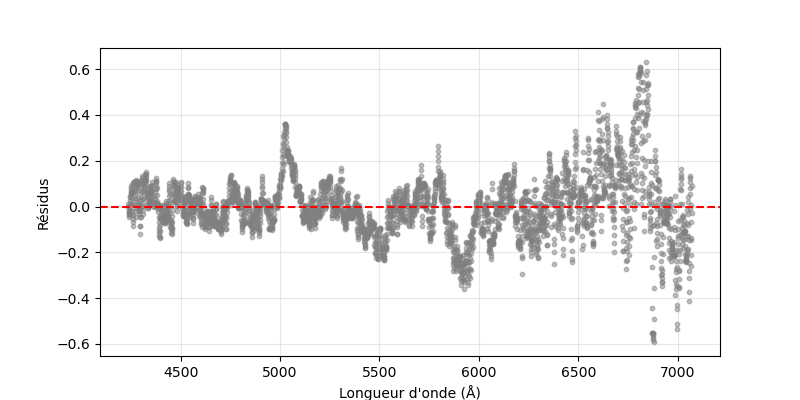

In [5]:
# on récupère les résidus en divisant le brut par le fit
residus = spectrum_sans_cont.flux - y_fit

# on affiche
fig, ax = plt.subplots(1, 1, figsize=(8, 4))#, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax.scatter(spectrum_sans_cont.spectral_axis, residus, s=10, color='gray', alpha=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_ylabel('Résidus')
ax.set_xlabel('Longueur d\'onde (Å)')
ax.grid(alpha=0.3)
plt.show()

# on vérifie que la zone de la raie est 'plate', ie le fit encadre bien la raie
